In [7]:
from simple_foraging_env import SimpleForagingEnv, SimpleAgent, RandomAgent, GreedySwitchAgent
from opponent_model import OpponentModel
from opponent_model_oracle import OpponentModelOracle
from q_agent import QLearningAgent, ReplayBuffer
from q_agent_classic import QLearningAgentClassic
from omg_args import OMGArgs
import transformers as t
import matplotlib.pyplot as plt
import torch
import os
import random
import numpy as np
from collections import deque
from typing import Deque, Dict, List, Tuple, Optional

In [8]:
import q_agent
import q_agent_classic
from maps import *


map_layout = MAP_5
map_name = "MAP_5"

om_id = 10687147
classic_id = 10686783
opponent_agent = GreedySwitchAgent(1)
# opponent_agent = SimpleAgent(1)


opponent_name = opponent_agent.__class__.__name__


device = "cuda" if torch.cuda.is_available() else "cpu"

env = SimpleForagingEnv(max_steps=50, map_layout=map_layout)

obs_sample = env.reset()[0]
H, W, F_dim = obs_sample.shape
NUM_ACTIONS = 4

args = OMGArgs(
  device=device,
  folder_id=0,
  batch_size=128,
  qnet_hidden=256,
  cnn_hidden=64,
  max_steps=70,
  tau_start=2.1,
  tau_end=0.01,
  state_shape=obs_sample.shape,
  H=H, W=W,
  action_dim=NUM_ACTIONS,
  d_model=64,
  nhead=4,
  num_encoder_layers=1,
  dim_feedforward=256,
  dropout=0.1,
)

inference_model = t.SpatialOpponentModel(args=args).to(args.device)
op_model = OpponentModel(model=inference_model, args=args)
q_agent = QLearningAgent(
    env=env,
    opponent_model=op_model,
    args=args
)
q_agent_classic = QLearningAgentClassic(
    env=env,
    args=args
)

In [9]:
qnet_path = f'./models/models_{om_id}/qnet.pth'
om_path = f'./models/models_{om_id}/opponent_model.pth'
classic_qnet_path = f'./models/models_{classic_id}/qnet.pth'

q_agent.q.load_state_dict(torch.load(qnet_path, map_location=args.device))
q_agent.model.inference_model.load_state_dict(torch.load(om_path, map_location=args.device))
q_agent_classic.q.load_state_dict(torch.load(classic_qnet_path, map_location=args.device))

<All keys matched successfully>

In [10]:
# functions to run episodes with the agents, used for testing and evaluation
from numpy import save


def run_om_episode(env, q_agent, opponent_agent, render=False):
  obs = env.reset()
  opponent_agent.reset()
  done = False
  ep_ret = 0.0

  history_len = q_agent.args.max_history_length
  history = {
      "states": deque(maxlen=history_len),
      "actions": deque(maxlen=history_len)
  }

  for step in range(50):
    current_history = {k: list(v) for k, v in history.items()}

    a, g_map = q_agent.select_action(
      obs[0], current_history, eval=True)
    a_opponent = opponent_agent.select_action(obs[1], eval=True)
    actions = {0: a, 1: a_opponent}

    if render:
      q_agent.heatmap_q_values(g_map, save=False)
      q_agent.heatmap_subgoal(g_map, save=False)
      # SimpleForagingEnv.render_from_obs(obs[0])

    next_obs, reward, done, info = env.step(actions)

    history["states"].append(obs[0].copy())
    history["actions"].append(a_opponent)

    ep_ret += reward[0]
    obs = next_obs

    if done:
      break
  return {"return": ep_ret, "steps": step + 1}

def run_classic_episode(env, q_agent_classic, opponent_agent, render=False):
  obs = env.reset()
  opponent_agent.reset()
  done = False
  ep_ret = 0.0

  for step in range(50):
    a = q_agent_classic.select_action(obs[0], eval=True)
    a_opponent = opponent_agent.select_action(obs[1], eval=True)
    actions = {0: a, 1: a_opponent}

    if render:
      q_agent_classic.heatmap_q_values(save=False)
      # SimpleForagingEnv.render_from_obs(obs[0])

    next_obs, reward, done, info = env.step(actions)

    ep_ret += reward[0]
    obs = next_obs

    if done:
      break
  return {"return": ep_ret, "steps": step + 1}


/home/marcel/miniforge3/envs/om/lib/python3.14/site-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


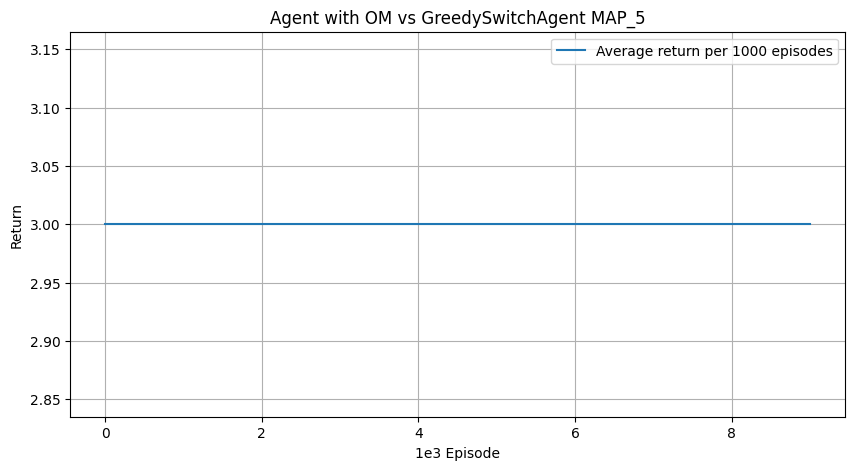

In [11]:
# Test OM agent
total_episodes = 10_000
avg_per = 1000
avg_returns = []
episode_returns = []
for episode in range(total_episodes):
  if (episode + 1) % 5000 == 0:
    results = run_om_episode(env, q_agent, opponent_agent, render=False)
  else:
    results = run_om_episode(env, q_agent, opponent_agent, render=False)
  episode_returns.append(results["return"])
  if (episode + 1) % avg_per == 0:
    avg_return = np.mean(episode_returns[-avg_per:])
    avg_returns.append(avg_return)

# plot returns
plt.figure(figsize=(10, 5))
plt.plot(avg_returns, label=f'Average return per {avg_per} episodes')
plt.xlabel('1e3 Episode')
plt.ylabel('Return')
plt.title(f'Agent with OM vs {opponent_name} {map_name}')
plt.legend()
plt.grid()
plt.savefig(f'{map_name}_{opponent_name}_OM.png')
plt.show()


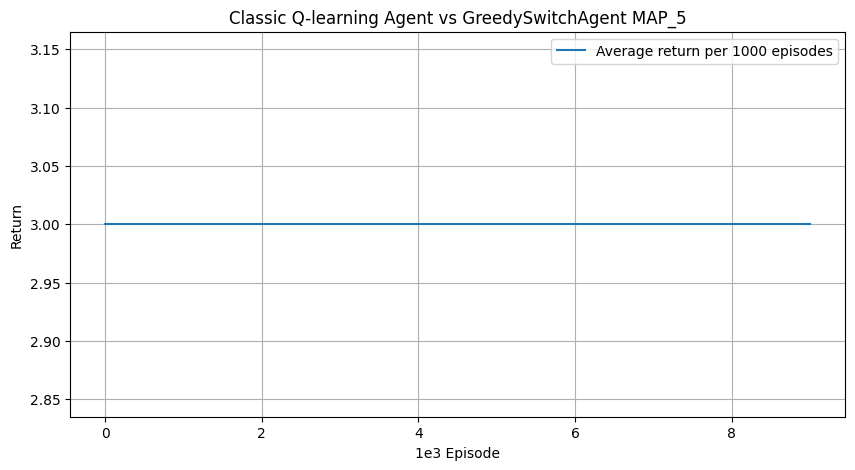

In [12]:
# Test classic agent
# Test OM agent
total_episodes = 10_000
avg_per = 1000
avg_returns = []
episode_returns = []
for episode in range(total_episodes):
  if (episode + 1) % 5_000 == 0:
    results = run_classic_episode(env, q_agent_classic, opponent_agent, render=False)
  else:
    results = run_classic_episode(env, q_agent_classic, opponent_agent, render=False)
  episode_returns.append(results["return"])
  if (episode + 1) % avg_per == 0:
    avg_return = np.mean(episode_returns[-avg_per:])
    avg_returns.append(avg_return)

# plot returns
plt.figure(figsize=(10, 5))
plt.plot(avg_returns, label=f'Average return per {avg_per} episodes')
plt.xlabel('1e3 Episode')
plt.ylabel('Return')
plt.title(f'Classic Q-learning Agent vs {opponent_name} {map_name}')
plt.legend()
plt.grid()
plt.savefig(f'{map_name}_{opponent_name}_classic.png')
plt.show()